In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score




In [2]:
# Chargement
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print(df.head())

print(df.info())

print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int6

In [3]:
df.shape

(150, 5)

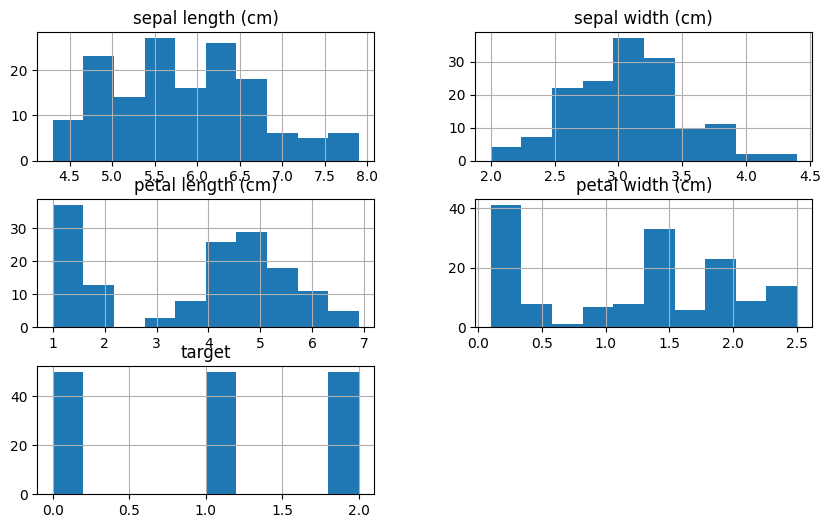

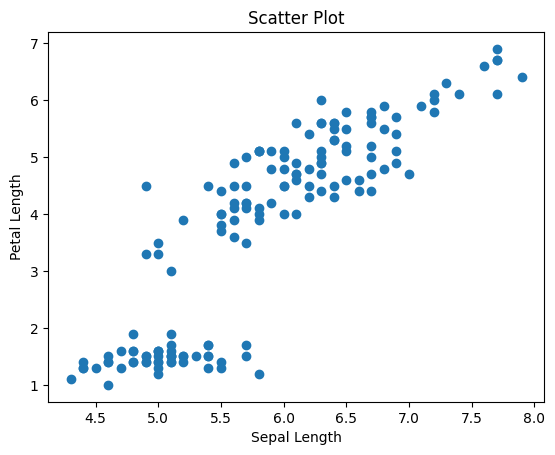

In [19]:
#visualisation DATA 

# Histogrammes
df.hist(figsize=(10,6))
plt.show()

# Scatter plot simple
plt.scatter(df['sepal length (cm)'], df['petal length (cm)'])
print()
print()
plt.xlabel("Sepal Length")
print()
plt.ylabel("Petal Length")
print()
plt.title("Scatter Plot")
print()
plt.show()

In [5]:
#Pretraitement 
X = df.drop('target', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

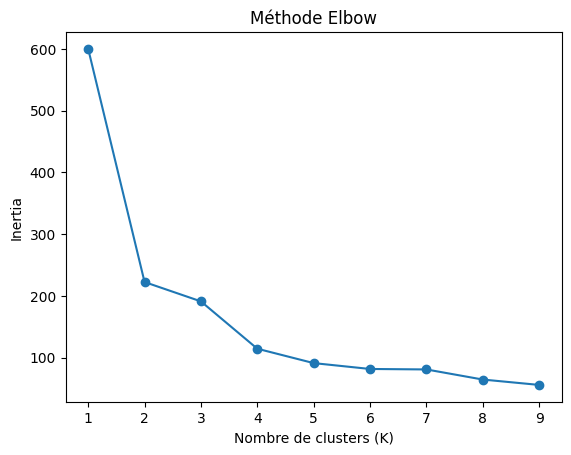

In [6]:
#Clustering 

# 1) K-means choix de K ELBOW Methode 

inertia = []
K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertia")
plt.title("Méthode Elbow")
plt.show()

In [7]:
#Silhouette Score

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.5817500491982808
K=3, Silhouette Score=0.4798814508199818
K=4, Silhouette Score=0.3850454053045392
K=5, Silhouette Score=0.34503345350274617
K=6, Silhouette Score=0.33394323040061763
K=7, Silhouette Score=0.2664290993719981
K=8, Silhouette Score=0.34162906041313373
K=9, Silhouette Score=0.3243991438983545


In [8]:
#modele final 

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

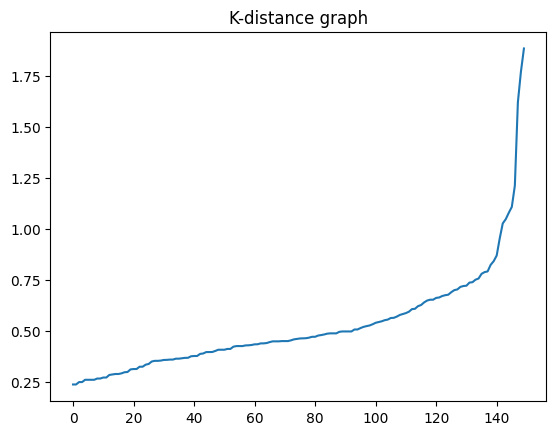

In [9]:
# k-distance graph pour trouver la valeur de eps=distance maximale entre deux voisins 



neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])  
plt.plot(distances)
plt.title("K-distance graph")
plt.show()

In [10]:
# 2) DBSCAN 

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

print("Nombre de clusters DBSCAN :", len(set(db_labels)) - (1 if -1 in db_labels else 0))

Nombre de clusters DBSCAN : 2


In [20]:
# 3)Agglomerative Clustering

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

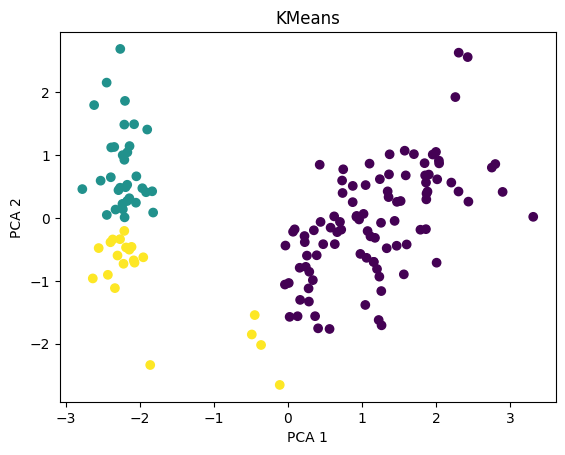

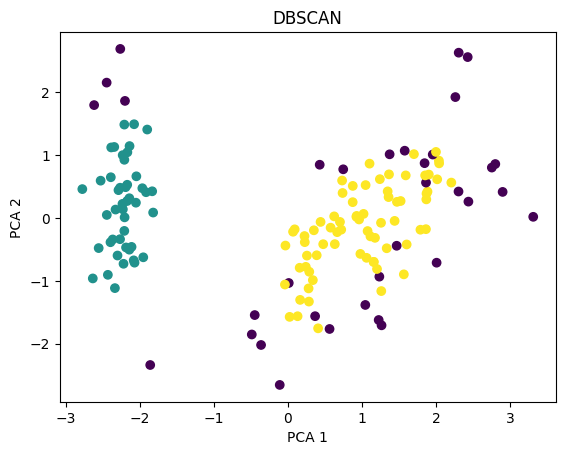

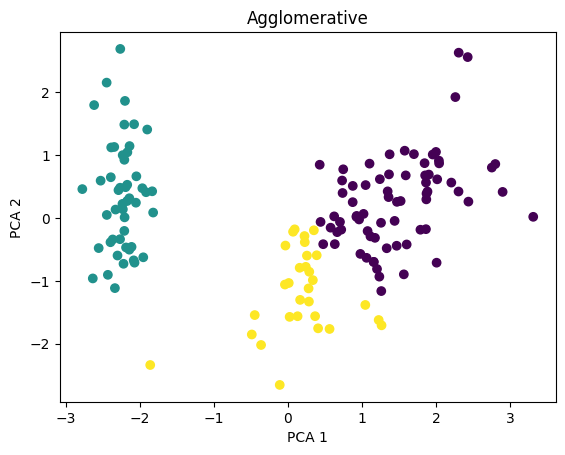

In [13]:
# Visualisation 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

def plot_clusters(labels, title):
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

plot_clusters(kmeans_labels, "KMeans")
plot_clusters(db_labels, "DBSCAN")
plot_clusters(agg_labels, "Agglomerative")

In [14]:
# Comparaison avec les vraies Labels 

#adjusted_rand_score


scores = {
    "KMeans": adjusted_rand_score(df['target'], kmeans_labels),
    "DBSCAN": adjusted_rand_score(df['target'], db_labels),
    "Agglomerative": adjusted_rand_score(df['target'], agg_labels)
}

scores_df = pd.DataFrame(scores, index=["ARI"]).T
print(scores_df.sort_values(by="ARI", ascending=False))

                    ARI
Agglomerative  0.615323
DBSCAN         0.442099
KMeans         0.432805


In [15]:
# evaluation de modele 

print("KMeans Silhouette :", silhouette_score(X_scaled, kmeans_labels))

# DBSCAN attention : ignorer le bruit
if len(set(db_labels)) > 1:
    print("DBSCAN Silhouette :", silhouette_score(X_scaled, db_labels))

print("Agglomerative Silhouette :", silhouette_score(X_scaled, agg_labels))

KMeans Silhouette : 0.4798814508199818
DBSCAN Silhouette : 0.3565164814270073
Agglomerative Silhouette : 0.446689041028591


In [16]:
#Davies-Bouldin Index


scores = {
    "KMeans": davies_bouldin_score(X_scaled, kmeans_labels),
    "DBSCAN": davies_bouldin_score(X_scaled, db_labels),
    "Agglomerative":davies_bouldin_score(X_scaled, agg_labels)
}

scores_df = pd.DataFrame(scores, index=["DBI"]).T
print(scores_df.sort_values(by="DBI", ascending=True))

                    DBI
KMeans         0.789363
Agglomerative  0.803467
DBSCAN         7.124057
